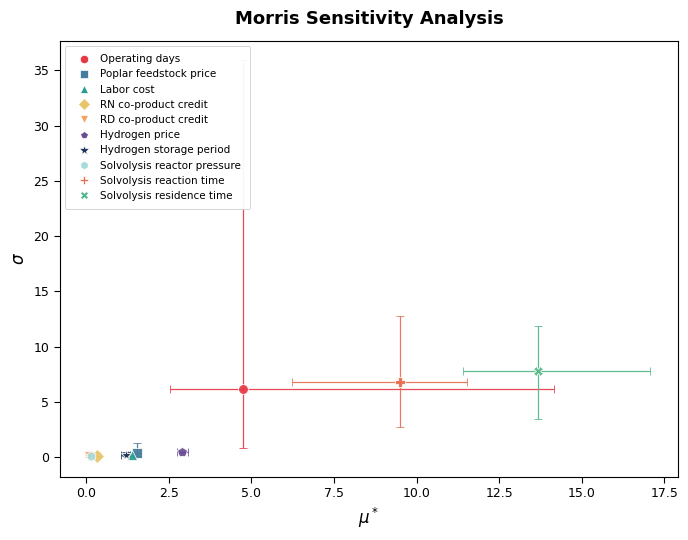

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import io

# ── Data ─────────────────────────────────────────────────────────────────────
DATA = """Feature,µ*,σ,Min µ*,Min σ,Max µ*,Max σ
Operating days,4.742444259,6.178463048,2.54323057,0.78967051,14.15241108,35.90405503
Poplar feedstock price,1.524133407,0.348799693,1.401522075,0.132393491,1.614792066,1.290503497
Labor cost,1.387731164,0.199682338,1.270407915,0.079025878,1.486549779,0.277871459
RN co-product credit,0.317216815,0.124093046,0.269296914,0.027485605,0.41645101,0.437253304
RD co-product credit,0.080235124,0.093113191,0.053466079,0.009885283,0.127681382,0.231239038
Hydrogen price,2.891087262,0.428618935,2.738287813,0.346279843,3.070091373,0.491413848
Hydrogen storage period,1.199830987,0.222748569,1.058890448,0.127240914,1.315846626,0.499000891
Solvolysis reactor pressure,0.13274678,0.125916925,0.072231075,0.038041151,0.221443167,0.362284506
Solvolysis reaction time,9.496813209,6.772004884,6.235688127,2.700424829,11.53122081,12.79744084
Solvolysis residence time,13.67901064,7.819182641,11.4053512,3.43462715,17.07659818,11.83708216
Solvolysis cleaning time,3.892340015,3.948554914,2.709744563,2.756836614,5.830788782,6.945740515
Methanol cost,2.082700041,1.374399833,1.420988511,0.646472906,2.978932715,2.419993181
RCF solvent losses,1.741601854,1.642918231,1.289605425,1.035552826,2.32924781,2.39459439
RCF catalyst price,0.035357601,0.069124963,0.006595916,0.009003327,0.137350849,0.324613499
RCF catalyst lifetime,0.059081248,0.143620686,0.011072083,0.01906668,0.272671133,0.83080962
RCF catalyst loading,0.046707402,0.101342227,0.017999297,0.033882815,0.126209843,0.293035944
Cellulose retention,7.407950519,4.042448619,5.935904689,1.441222323,11.08593804,8.80020411
Xylose retention,8.567022144,3.739569587,6.943609116,1.573959542,10.90555031,10.27620725
Delignfication,38.79059109,68.73869334,7.550474111,6.518690139,107.8832248,235.2582265
Condensation extent,47.42408156,76.82922054,11.46743145,10.34760773,123.9406165,237.039671
HDO reaction time,3.380789636,1.572356408,2.959840855,0.869722161,4.082329415,2.149409358
HDO solvent loading,62.99724751,113.0806236,22.24951712,8.598055116,117.1821449,297.5339329
HDO catalyst loading,0.39704563,0.385037894,0.197508977,0.134761856,0.7157969,0.70596286
HDO catalyst lifetime,0.72303948,0.781369764,0.338196962,0.330066802,1.221395325,1.0798297
Dodecane cost,9.547434597,4.341069994,6.414396792,2.80875386,12.68740385,6.309512705
Glucose to ethanol conv.,5.211660676,3.400234322,4.262224045,0.927589202,7.84661376,11.45629174
Glucan to glucose conv.,3.857383342,2.274440417,2.800479685,0.932849004,6.222248109,10.24222391
Saccharification residence time,0.06791842,0.079509934,0.041856132,0.00491974,0.141667559,0.268339056
Cofermentation residence time,0.061132996,0.107086221,0.025886698,0.004792596,0.133385712,0.3322433
Xylose to ethanol conv.,0.535511966,0.412054839,0.310942691,0.182961313,0.738229022,0.691527908
Xylan to xylose conversion,0.548732894,0.410678948,0.416451718,0.271257545,0.70433927,0.739589836
Cellulase enzyme loading,3.899979,1.48726709,2.845881387,1.014590697,4.531029643,1.970405276
Cellulase price,3.16944226,1.579396265,2.286876197,1.239065448,3.846810868,2.046646654
Et oac solvent to crude ratio,1.336976558,0.504033975,0.94232122,0.330926951,1.533216809,0.771975564
Ethyl acetate price,3.155328109,0.908132988,2.784170417,0.479504446,3.636393548,1.307944884
Hexane solvent to pure oil ratio,1.801974544,1.1602312,1.377983007,0.407383201,2.9531968,3.105062865
Hexane price,0.925423876,0.503709977,0.76845854,0.354860658,1.186559757,0.739532198"""

df = pd.read_csv(io.StringIO(DATA))

# ── Parameters to include ────────────────────────────────────────────────────
PARAMS = [
    'Operating days',
    'Poplar feedstock price',
    'Labor cost',
    'RN co-product credit',
    'RD co-product credit',
    'Hydrogen price',
    'Hydrogen storage period',
    'Solvolysis reactor pressure',
    'Solvolysis reaction time',
    'Solvolysis residence time',
]
# ─────────────────────────────────────────────────────────────────────────────

# Style per parameter: (marker, facecolor)
STYLES = [
    ('o',  '#e63946'),
    ('s',  '#457b9d'),
    ('^',  '#2a9d8f'),
    ('D',  '#e9c46a'),
    ('v',  '#f4a261'),
    ('p',  '#6a4c93'),
    ('*',  '#1d3557'),
    ('h',  '#a8dadc'),
    ('P',  '#e76f51'),
    ('X',  '#52b788'),
]

df = df[df['Feature'].isin(PARAMS)].set_index('Feature').loc[PARAMS]

mu     = df['µ*'].values
sigma  = df['σ'].values
xerr   = [mu - df['Min µ*'].values, df['Max µ*'].values - mu]
yerr   = [sigma - df['Min σ'].values, df['Max σ'].values - sigma]
labels = df.index.values

# ── figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5.5))

legend_handles = []

for i, (lbl, (marker, color)) in enumerate(zip(labels, STYLES)):
    ax.errorbar(
        mu[i], sigma[i],
        xerr=[[xerr[0][i]], [xerr[1][i]]],
        yerr=[[yerr[0][i]], [yerr[1][i]]],
        fmt=marker,
        color=color,
        ecolor=color,
        elinewidth=0.9,
        capsize=3,
        capthick=0.9,
        markersize=8 if marker == '*' else 7,
        markeredgewidth=0.6,
        markeredgecolor='white',
        alpha=0.92,
        zorder=3,
    )
    handle = mlines.Line2D(
        [], [], marker=marker, color=color,
        linestyle='None',
        markersize=7 if marker == '*' else 6,
        markeredgewidth=0.5,
        markeredgecolor='white',
        label=lbl,
    )
    legend_handles.append(handle)

ax.set_xlabel(r'$\mu^*$', fontsize=12)
ax.set_ylabel(r'$\sigma$', fontsize=12)
ax.set_title('Morris Sensitivity Analysis', fontsize=13, fontweight='bold', pad=12)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)
ax.tick_params(labelsize=9, length=4, width=0.8)

legend = ax.legend(
    handles=legend_handles,
    fontsize=7.5,
    frameon=True,
    framealpha=0.95,
    edgecolor='#cccccc',
    loc='upper left',
    handletextpad=0.6,
    borderpad=0.8,
    labelspacing=0.5,
)
legend.get_frame().set_linewidth(0.6)

plt.tight_layout()
plt.savefig('morris_scatter.png', dpi=220, bbox_inches='tight')
plt.show()